# SETUP for RADMC3D
## Loading and analyzing the model from Fargo3d

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

In [2]:
path_start = f"/pfs/10/work/hd_cu284-work/fargo3d/outputs/"
path_endings=["fargo_fiducial_2gen", "fargo_high_mass_2gen",  "fargo_low_mass_2gen", "fargo_high_visc_2gen", "fargo_low_visc_2gen",
              "fargo_sigslop_0_2gen","fargo_sigslop_0.5_2gen", "fargo_sigslop_-2_2gen", ]

paths = []
for i in range(len(path_endings)):
    paths.append(path_start+path_endings[i])

In [3]:


frames = [0,100]

rho_cube=[] # first index: which alpha, second index: which snapshot.
for path in paths:
    rho_cube.append([])
    for i in frames:
        rho = np.fromfile(f"{path}/gasdens{i}.dat").reshape(300, 384)
        rho_cube[-1].append(rho)

rho_cube=np.array(rho_cube)

In [4]:
"""
%matplotlib inline
r_min = 0.3
r_max = 7

for i in range(len(paths)):
    plt.figure(figsize=(6*len(frames),5))
    path = paths[i]
    for it,frame in enumerate(frames):
        if frame ==0:
            continue
        plt.subplot(1,len(frames),it+1)
        plt.imshow(np.log10(rho_cube[i][it]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)])
        plt.title(f"$\\log \\Sigma$, {path[43:-5]}, {(frame)*10} orbits")
        plt.ylabel("$log10(r/r_0)$")
        plt.colorbar()
"""

'\n%matplotlib inline\nr_min = 0.3\nr_max = 7\n\nfor i in range(len(paths)):\n    plt.figure(figsize=(6*len(frames),5))\n    path = paths[i]\n    for it,frame in enumerate(frames):\n        if frame ==0:\n            continue\n        plt.subplot(1,len(frames),it+1)\n        plt.imshow(np.log10(rho_cube[i][it]), origin=\'lower\', cmap=cm.Oranges_r, aspect=\'auto\',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)])\n        plt.title(f"$\\log \\Sigma$, {path[43:-5]}, {(frame)*10} orbits")\n        plt.ylabel("$log10(r/r_0)$")\n        plt.colorbar()\n'

In [5]:

Nr = 300
Nphi = 384

r_list = np.fromfile(f"{path}/domain_y.dat", sep="\n")[3:-4]
phi = np.linspace(0, 2*np.pi, Nphi)

R, PHI = np.meshgrid(r_list, phi, indexing='ij')

In [6]:
"""

%matplotlib inline
r_min = 0.3
r_max = 7


for i in range(len(paths)):
    plt.figure(figsize=(6*len(frames),5))
    path = paths[i]
    for it,frame in enumerate(frames):
        if frame==0:
            continue
        plt.subplot(1,len(frames),it+1)
        plt.pcolormesh(PHI, R, np.log10(rho_cube[i][it]),cmap=cm.Oranges_r, shading='auto')
        plt.xlabel("$\\varphi$")
        plt.ylabel("$r/r_p$")
        plt.title(f"$\\log \\Sigma$, {path[43:-5]}, {(frame)*10} orbits")
        plt.colorbar()
"""

'\n\n%matplotlib inline\nr_min = 0.3\nr_max = 7\n\n\nfor i in range(len(paths)):\n    plt.figure(figsize=(6*len(frames),5))\n    path = paths[i]\n    for it,frame in enumerate(frames):\n        if frame==0:\n            continue\n        plt.subplot(1,len(frames),it+1)\n        plt.pcolormesh(PHI, R, np.log10(rho_cube[i][it]),cmap=cm.Oranges_r, shading=\'auto\')\n        plt.xlabel("$\\varphi$")\n        plt.ylabel("$r/r_p$")\n        plt.title(f"$\\log \\Sigma$, {path[43:-5]}, {(frame)*10} orbits")\n        plt.colorbar()\n'

# Turning this into a setup for radmc3d

You can also find this in `altered_setup.py`

In [7]:
import os
# so it can find Radmc3D
os.environ["PATH"] += ":/home/hd/hd_hd/hd_cu284/bin"
# so it can find other libraries Radmc3D depends on that I cannot access from inside the singularity container.
# DO NOT TOUCH!!!!
os.environ["LD_LIBRARY_PATH"] = "/home/hd/hd_hd/hd_cu284/libs:" + os.environ.get("LD_LIBRARY_PATH", "")
# Change path to dir that contains all the radmc3d-relevant files, like dust_density.inp etc.
os.chdir("/home/hd/hd_hd/hd_cu284/jupyter notebooks/thesis_suited_plots_maybe/radmc3d_sims")

### REMEMBER TO CHANGE THESE PATHS IF NECESSARY!

In [8]:
import sys
# python won't find the helper files otherwise.
sys.path.append("/home/hd/hd_hd/hd_cu284/jupyter notebooks/thesis_suited_plots_maybe/radmc3d_sims")

import os

# Add the library path for libgfortran.so.5
os.environ['LD_LIBRARY_PATH'] = '/usr/lib64:' + os.environ.get('LD_LIBRARY_PATH', '')


# Shorter:

In [9]:
from altered_setup import main
path = f"/pfs/10/work/hd_cu284-work/fargo3d/outputs/fargo_fiducial_2gen"
sigma_dust_2d = main(path, dens=1)

# Kernel dies if you try to run this twice. Why? No idea.

Fast (Fortran90) Mie-scattering module could not be imported. Falling back to the slower Python version.
1 dust species detected!
Please check that the RADMC-3D setup is roughly consistent with the FARGO3D setup:
  AspectRatio in RADMC-3D model at R0  = 0.06912608418792082
  FlaringIndex in RADMC-3D model at R0 = 0.24934156881001246
If these values are vastly different from those in the FARGO3D .par file,
you should either modify the parameters in the RADMC-3D model, or the parameters
in the FARGO3D model, to make them both mutually self-consistent.
Reading dustkapscatmat_1.00e-01.inp


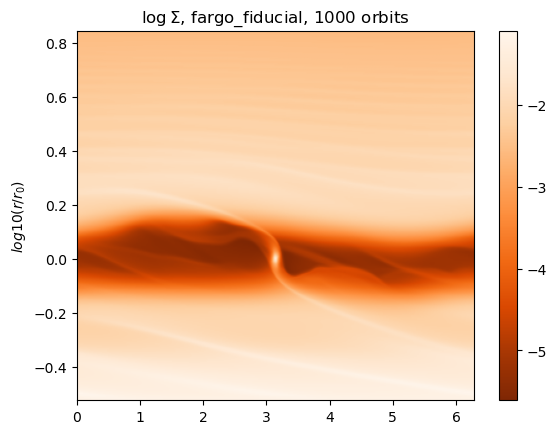

In [10]:
r_min = 0.3
r_max = 7

# Check the input:
plt.imshow(np.log10(sigma_dust_2d[0]),origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)])
plt.title(f"$\\log \\Sigma$, {path[43:-5]}, {(frames[-1])*10} orbits")
plt.ylabel("$log10(r/r_0)$")
plt.colorbar()
plt.show()

## Investigating opacity $\tau$

We make a rough estimate for particles of size 0.1µm (the ones we used here) with data from the dustkapscatmat_1.00e-01.inp file. We start with the k band, which is centered at approx 2µm. We use this line from the dustkapscatmat file:

`0.233894E+00  0.290097E+05  0.320072E+05  0.762248E+00`

The leftmost value is $\lambda$ in µm, followed by $\kappa_{abs}$ and $\kappa_{scat}$ and $g = <\cos \theta>$.
We use $\kappa = \kappa_{abs}+\kappa_{scat}$

In [11]:
path = "/home/hd/hd_hd/hd_cu284/jupyter notebooks/thesis_suited_plots_maybe/radmc3d_sims"
## caution: I figured out skiprows and maxrows by trial-and-error. 
dustkapscatmat= np.loadtxt(f"{path}/dustkapscatmat_1.00e-01.inp", comments="#", skiprows=17,max_rows=150)

wavelengths = np.array(dustkapscatmat[:,0])
kappa_abs = np.array(dustkapscatmat[:,1])
kappa_scat = np.array(dustkapscatmat[:,2])
kappa_tot = kappa_abs+kappa_scat

lambda_K = 2.2 #µm
lambda_H = 1.65 #µm

kappa_tot_K, kappa_tot_H = np.interp([lambda_K, lambda_H], wavelengths, kappa_tot) # cm²/g


In [17]:
sigma_mean = np.mean(sigma_dust_2d[0], axis=1)
tau_K = kappa_tot_K * sigma_mean
tau_H = kappa_tot_H * sigma_mean
print("kappa_tot_K:", kappa_tot_K)
print("kappa_tot_H:", kappa_tot_H)

kappa_tot_K: 327.86636079024055
kappa_tot_H: 946.506869910016


Minimum optical depth (K band): 0.005458550686372949
Minimum optical depth (H band): 0.01575811471463961


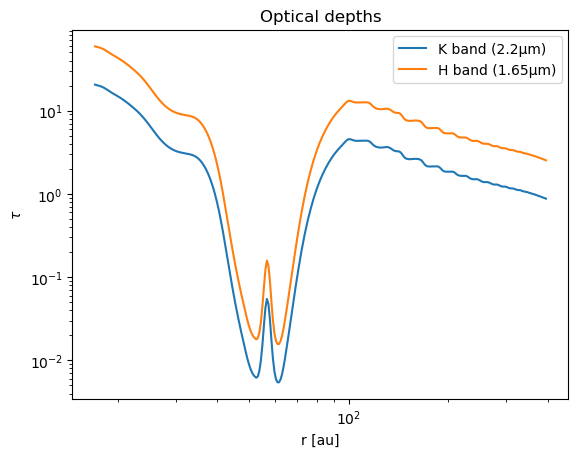

In [21]:

plt.plot(r_list*57, tau_K, label="K band (2.2µm)")
plt.plot(r_list*57, tau_H, label="H band (1.65µm)")

plt.yscale("log")
plt.xscale("log")
plt.xlabel("r [au]")
plt.ylabel("$\\tau$")
plt.title("Optical depths")
plt.legend()

print("Minimum optical depth (K band):", min(tau_K))
print("Minimum optical depth (H band):", min(tau_H))

Text(0.5, 1.0, 'Dust density')

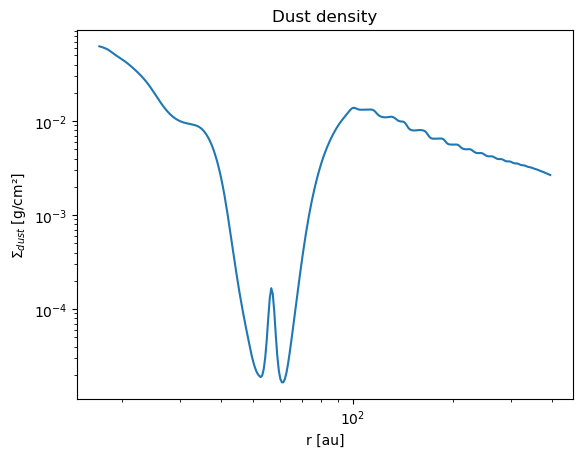

In [20]:
plt.plot(r_list*57, sigma_mean)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("r [au]")
plt.ylabel("$\\Sigma_{dust}$ [g/cm²]")
plt.title("Dust density")

In [ ]:
## put problem_setup.py here if necessary.